# Notebook 2 — Spatial Analysis: Kriging & Moran's I

**Inputs:** `soil_long.csv` (from Notebook 1)  
**Scope:** Map the spatial distribution of clay, pH, and organic carbon across Southern Africa using Ordinary Kriging, and measure spatial autocorrelation with Moran's I.

> **Outputs saved:**  
> `morans_results.csv`

---
### Dependencies
Run the install cell below once if `pykrige`, `libpysal`, or `esda` are not yet installed.

In [1]:
# Run once — safe to skip if packages already installed
# !pip install pykrige libpysal esda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.3 MB/s eta 0:00:00


In [2]:
# ── 2.1  Imports & style ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from pykrige.ok import OrdinaryKriging
import libpysal
from esda.moran import Moran, Moran_Local

# ── Palette (mirrored from Notebook 1) ───────────────────────────────────────
PALETTE = {
    "acid":     "#8B0000",
    "neutral":  "#2E7D32",
    "alkaline": "#1E88E5",
    "sand":     "#F5E6C4",
    "charcoal": "#2B2B2B"
}
VAR_COLORS = {"clay": "#A0522D", "ph": "#1E88E5", "orgc": "#2E7D32"}
VAR_CMAPS  = {"clay": "YlOrBr",  "ph": "RdYlBu",  "orgc": "YlGn"}
VAR_LABELS = {"clay": "Clay (%)", "ph": "pH", "orgc": "Organic Carbon (%)"}

BBOX     = {"lon_min": 11.5, "lon_max": 40.0, "lat_min": -35.0, "lat_max": -15.0}
GRID_RES = 0.5   # degrees — kriging interpolation resolution
DECADES  = ["1960s", "1970s", "1980s", "1990s", "2000s"]

plt.rcParams.update({
    "figure.figsize":   (8, 5),
    "axes.facecolor":   PALETTE["sand"],
    "figure.facecolor": PALETTE["sand"],
    "text.color":       PALETTE["charcoal"]
})
def clean_plot():
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()

print("Style loaded.")

Style loaded.


## 2.2 Load data

In [3]:
soil_long = pd.read_csv("soil_long.csv")

# Working frame: Surface layer, dateable records only, no nulls in value_avg
surface = soil_long[
    (soil_long["depth_category"] == "Surface") &
    soil_long["decade"].notna() &
    soil_long["value_avg"].notna()
].copy()

print(f"Surface records (datable, non-null): {len(surface):,}")
print()
print(surface.groupby(["variable", "decade"]).size().unstack(fill_value=0))

Surface records (datable, non-null): 6,724

decade    1940s  1960s  1970s  1980s  1990s  2000s
variable                                          
clay          2    101    814   1024    212    114
orgc          2     99    804    982    199     83
ph            2    108    837   1026    208    107


## 2.3 Kriging helpers

In [4]:
def get_surface_var(df, variable, decade=None):
    """Filter surface data for a variable, optionally narrowed to one decade."""
    subset = df[df["variable"] == variable].copy()
    if decade:
        subset = subset[subset["decade"] == decade]
    return subset.dropna(subset=["value_avg", "longitude", "latitude"])


def krige_variable(df_subset, grid_res=GRID_RES, bbox=BBOX):
    """
    Fit Ordinary Kriging (spherical variogram) and return predicted grid values.

    Returns
    -------
    z_grid   : masked array of predicted values on the grid
    grid_lon : 1-D longitude array
    grid_lat : 1-D latitude array
    All three are None if fewer than 15 sample points are available.
    """
    if len(df_subset) < 15:
        return None, None, None

    x = df_subset["longitude"].values
    y = df_subset["latitude"].values
    z = df_subset["value_avg"].values

    grid_lon = np.arange(bbox["lon_min"], bbox["lon_max"] + grid_res, grid_res)
    grid_lat = np.arange(bbox["lat_min"], bbox["lat_max"] + grid_res, grid_res)

    ok = OrdinaryKriging(
        x, y, z,
        variogram_model="spherical",
        verbose=False,
        enable_plotting=False
    )
    z_grid, _ = ok.execute("grid", grid_lon, grid_lat)
    return z_grid, grid_lon, grid_lat

## 2.4 Variogram illustration

Before mapping, we inspect the empirical variogram for one variable and decade. The variogram shows *how rapidly spatial correlation decays with distance* — it is the statistical backbone of the kriging model.

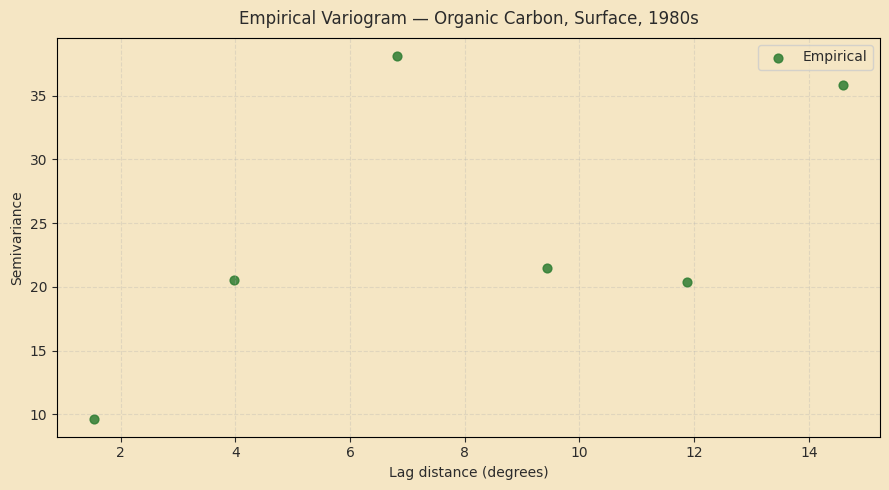


Interpretation: semivariance rises from the nugget (y-intercept) to the sill (plateau).
The lag at which it plateaus is the range — beyond that distance, locations are uncorrelated.


In [5]:
sample_var    = "orgc"
sample_decade = "1980s"
sample_df     = get_surface_var(surface, sample_var, sample_decade)

ok_demo = OrdinaryKriging(
    sample_df["longitude"].values,
    sample_df["latitude"].values,
    sample_df["value_avg"].values,
    variogram_model="spherical",
    verbose=False,
    enable_plotting=False
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(ok_demo.lags, ok_demo.semivariance,
           color=VAR_COLORS[sample_var], s=40, alpha=0.85, label="Empirical")
ax.set_title(f"Empirical Variogram — Organic Carbon, Surface, {sample_decade}",
             color=PALETTE["charcoal"], fontsize=12, pad=10)
ax.set_xlabel("Lag distance (degrees)", color=PALETTE["charcoal"])
ax.set_ylabel("Semivariance",           color=PALETTE["charcoal"])
ax.tick_params(colors=PALETTE["charcoal"])
ax.legend(facecolor=PALETTE["sand"], labelcolor=PALETTE["charcoal"])
clean_plot()
plt.show()

print("\nInterpretation: semivariance rises from the nugget (y-intercept) to the sill (plateau).")
print("The lag at which it plateaus is the range — beyond that distance, locations are uncorrelated.")

## 2.5 Single kriged map — primary illustration

Organic carbon, Surface layer, 1980s (densest decade).

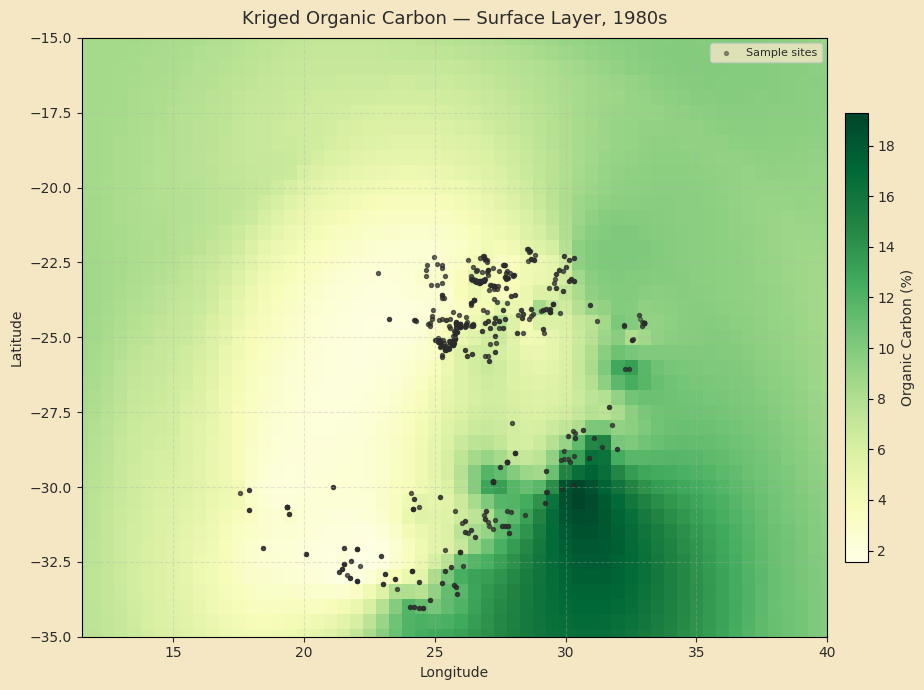

In [6]:
z_grid, grid_lon, grid_lat = krige_variable(sample_df)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.pcolormesh(grid_lon, grid_lat, z_grid,
                   cmap=VAR_CMAPS[sample_var], shading="auto")
ax.scatter(sample_df["longitude"], sample_df["latitude"],
           s=8, color=PALETTE["charcoal"], alpha=0.45, label="Sample sites")

cb = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cb.set_label(VAR_LABELS[sample_var], color=PALETTE["charcoal"])
cb.ax.tick_params(labelcolor=PALETTE["charcoal"])

ax.set_xlim(BBOX["lon_min"], BBOX["lon_max"])
ax.set_ylim(BBOX["lat_min"], BBOX["lat_max"])
ax.set_title(f"Kriged Organic Carbon — Surface Layer, {sample_decade}",
             color=PALETTE["charcoal"], fontsize=13, pad=10)
ax.set_xlabel("Longitude", color=PALETTE["charcoal"])
ax.set_ylabel("Latitude",  color=PALETTE["charcoal"])
ax.tick_params(colors=PALETTE["charcoal"])
ax.legend(fontsize=8, facecolor=PALETTE["sand"], labelcolor=PALETTE["charcoal"])
clean_plot()
plt.show()

## 2.6 Multi-decade kriging panel

Rows = decades · Columns = variables. Use a consistent colormap per variable so spatial change reads visually across rows.

LinAlgError: singular matrix

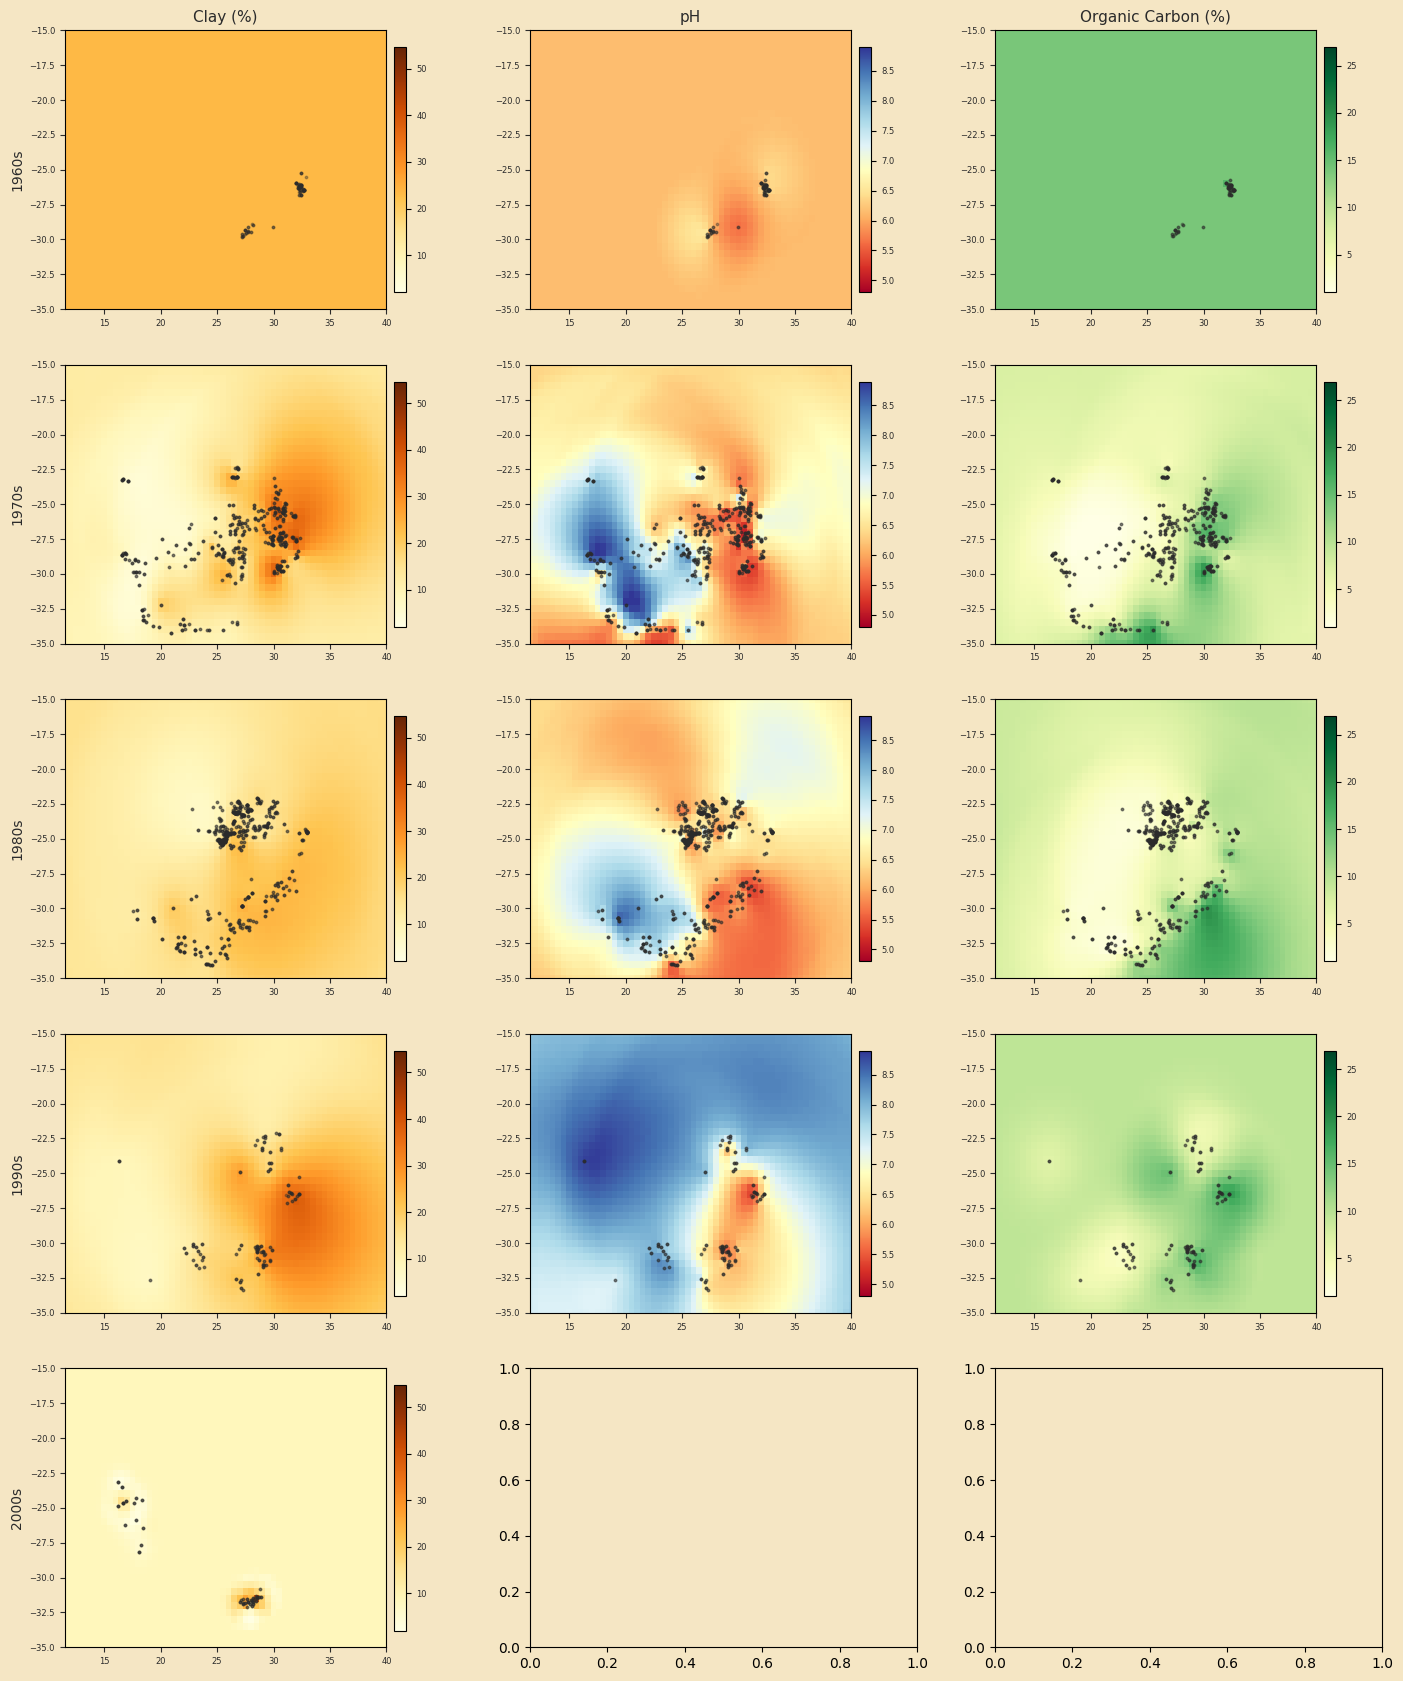

In [7]:
n_rows = len(DECADES)
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, n_rows * 4 + 1))
fig.patch.set_facecolor(PALETTE["sand"])

# Store per-variable colour limits so all decades share the same scale
vlims = {}
for var in ["clay", "ph", "orgc"]:
    all_vals = surface[surface["variable"] == var]["value_avg"].dropna()
    vlims[var] = (np.percentile(all_vals, 2), np.percentile(all_vals, 98))

for row, decade in enumerate(DECADES):
    for col, var in enumerate(["clay", "ph", "orgc"]):
        ax = axes[row, col]
        ax.set_facecolor(PALETTE["sand"])
        df_sub = get_surface_var(surface, var, decade)
        z_grid, grid_lon, grid_lat = krige_variable(df_sub)

        if z_grid is None:
            ax.text(0.5, 0.5, f"Insufficient data\n({len(df_sub)} pts)",
                    ha="center", va="center", transform=ax.transAxes,
                    color=PALETTE["charcoal"], fontsize=9)
        else:
            im = ax.pcolormesh(
                grid_lon, grid_lat, z_grid,
                cmap=VAR_CMAPS[var], shading="auto",
                vmin=vlims[var][0], vmax=vlims[var][1]
            )
            ax.scatter(df_sub["longitude"], df_sub["latitude"],
                       s=3, color=PALETTE["charcoal"], alpha=0.35)
            plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02).ax.tick_params(
                labelcolor=PALETTE["charcoal"], labelsize=6)

        ax.set_xlim(BBOX["lon_min"], BBOX["lon_max"])
        ax.set_ylim(BBOX["lat_min"], BBOX["lat_max"])
        ax.tick_params(colors=PALETTE["charcoal"], labelsize=6)

        if row == 0:
            ax.set_title(VAR_LABELS[var], color=PALETTE["charcoal"], fontsize=11, pad=6)
        if col == 0:
            ax.set_ylabel(decade, color=PALETTE["charcoal"], fontsize=10)

plt.suptitle("Kriged Soil Properties — Surface Layer by Decade",
             color=PALETTE["charcoal"], fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2.7 Global Moran's I — spatial autocorrelation over time

**Moran's I** measures whether similar values cluster geographically (I > 0) or disperse (I < 0).  
We compute it for each variable × decade on the Surface layer and track how spatial structure evolves.

In [8]:
def compute_morans_i(df_subset, k=8):
    """
    Compute Global Moran's I using a k-nearest-neighbour spatial weights matrix.
    Returns (I, p_value) or (NaN, NaN) if fewer than k+1 observations.
    """
    df_sub = df_subset.dropna(subset=["value_avg", "longitude", "latitude"])
    if len(df_sub) < k + 1:
        return np.nan, np.nan
    coords = list(zip(df_sub["longitude"], df_sub["latitude"]))
    w = libpysal.weights.KNN(coords, k=k)
    w.transform = "R"
    mi = Moran(df_sub["value_avg"].values, w, permutations=499)
    return float(mi.I), float(mi.p_sim)


print("Computing Moran's I across decades and variables...")
print("-" * 52)
morans_records = []

for var in ["clay", "ph", "orgc"]:
    for decade in DECADES:
        df_sub = get_surface_var(surface, var, decade)
        I, p   = compute_morans_i(df_sub)
        morans_records.append({"variable": var, "decade": decade,
                               "morans_I": I, "p_value": p})
        if not np.isnan(I):
            sig = "✓" if p < 0.05 else "–"
            print(f"  {var:5s}  {decade}   I = {I:+.3f}   p = {p:.3f}  {sig}")
        else:
            print(f"  {var:5s}  {decade}   insufficient data")

morans_df = pd.DataFrame(morans_records)
morans_df.to_csv("morans_results.csv", index=False)
print("\n✓ Saved morans_results.csv")

Computing Moran's I across decades and variables...
----------------------------------------------------
  clay   1960s   I = +0.355   p = 0.002  ✓
  clay   1970s   I = +0.643   p = 0.002  ✓
  clay   1980s   I = +0.374   p = 0.002  ✓
  clay   1990s   I = +0.433   p = 0.002  ✓
  clay   2000s   I = +0.598   p = 0.002  ✓
  ph     1960s   I = +0.192   p = 0.002  ✓
  ph     1970s   I = +0.730   p = 0.002  ✓
  ph     1980s   I = +0.554   p = 0.002  ✓
  ph     1990s   I = +0.582   p = 0.002  ✓
  ph     2000s   I = +0.863   p = 0.002  ✓
  orgc   1960s   I = +0.346   p = 0.002  ✓
  orgc   1970s   I = +0.621   p = 0.002  ✓
  orgc   1980s   I = +0.518   p = 0.002  ✓
  orgc   1990s   I = +0.511   p = 0.002  ✓
  orgc   2000s   I = +0.505   p = 0.002  ✓

✓ Saved morans_results.csv


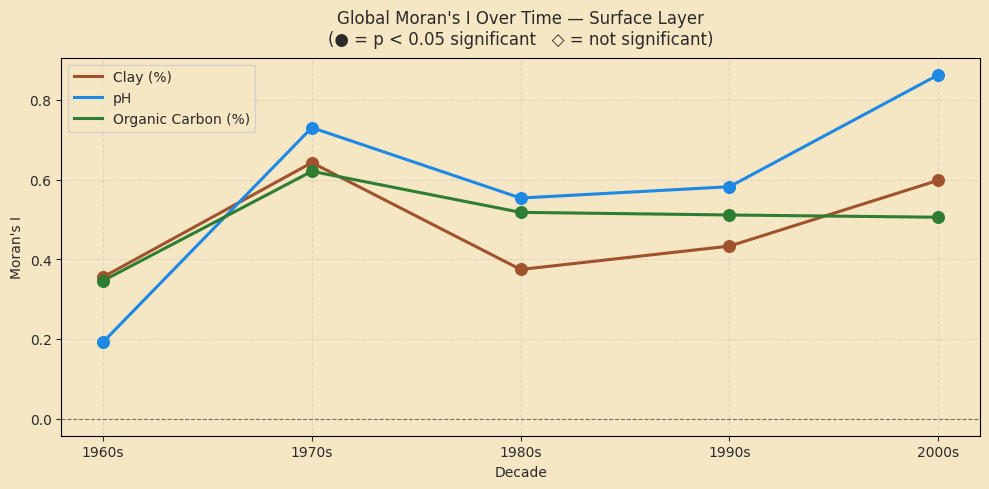

In [9]:
# ── Plot Moran's I over time ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for var in ["clay", "ph", "orgc"]:
    sub   = morans_df[(morans_df["variable"] == var) & morans_df["morans_I"].notna()]
    sig   = sub[sub["p_value"] < 0.05]
    insig = sub[sub["p_value"] >= 0.05]

    ax.plot(sub["decade"], sub["morans_I"],
            color=VAR_COLORS[var], linewidth=2.2, label=VAR_LABELS[var])
    ax.scatter(sig["decade"],   sig["morans_I"],
               color=VAR_COLORS[var], s=70, zorder=5)
    ax.scatter(insig["decade"], insig["morans_I"],
               color=VAR_COLORS[var], s=70, marker="D",
               facecolors="none", linewidths=1.5, zorder=5)

ax.axhline(0, color=PALETTE["charcoal"], linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_title("Global Moran's I Over Time — Surface Layer\n"
             "(● = p < 0.05 significant   ◇ = not significant)",
             color=PALETTE["charcoal"], fontsize=12, pad=10)
ax.set_xlabel("Decade", color=PALETTE["charcoal"])
ax.set_ylabel("Moran's I", color=PALETTE["charcoal"])
ax.tick_params(colors=PALETTE["charcoal"])
ax.legend(facecolor=PALETTE["sand"], labelcolor=PALETTE["charcoal"])
clean_plot()
plt.show()

## 2.8 LISA cluster map — Local Moran's I

Where are the spatial clusters? Local Moran's I (LISA) flags individual locations as:
- **High–High:** high value surrounded by high values  
- **Low–Low:** low value surrounded by low values  
- **High–Low / Low–High:** spatial outliers  
- **Non-significant:** no detectable local clustering

Illustrated here for organic carbon in the 1990s — the most recent well-covered decade before data thins.

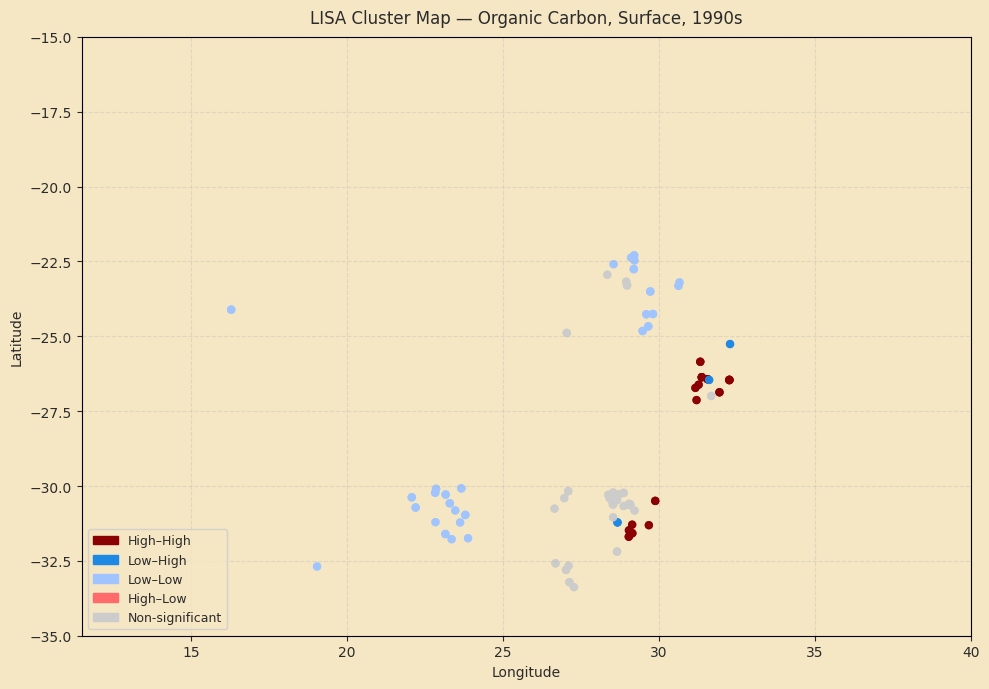

In [10]:
lisa_var    = "orgc"
lisa_decade = "1990s"
df_lisa     = get_surface_var(surface, lisa_var, lisa_decade)

coords  = list(zip(df_lisa["longitude"], df_lisa["latitude"]))
w_lisa  = libpysal.weights.KNN(coords, k=8)
w_lisa.transform = "R"
lisa    = Moran_Local(df_lisa["value_avg"].values, w_lisa, permutations=499)

# 1=HH, 2=LH, 3=LL, 4=HL; 0=non-significant
sig_mask = lisa.p_sim < 0.05
labels   = np.where(sig_mask, lisa.q, 0)

LISA_COLORS = {1: "#8B0000", 2: "#1E88E5", 3: "#A0C4FF", 4: "#FF6B6B", 0: "#CCCCCC"}
point_colors = [LISA_COLORS[int(l)] for l in labels]

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor(PALETTE["sand"])
ax.scatter(df_lisa["longitude"], df_lisa["latitude"],
           c=point_colors, s=25, alpha=0.85)
ax.set_xlim(BBOX["lon_min"], BBOX["lon_max"])
ax.set_ylim(BBOX["lat_min"], BBOX["lat_max"])
ax.set_title(f"LISA Cluster Map — Organic Carbon, Surface, {lisa_decade}",
             color=PALETTE["charcoal"], fontsize=12, pad=10)
ax.set_xlabel("Longitude", color=PALETTE["charcoal"])
ax.set_ylabel("Latitude",  color=PALETTE["charcoal"])
ax.tick_params(colors=PALETTE["charcoal"])

legend_elements = [
    mpatches.Patch(color="#8B0000", label="High–High"),
    mpatches.Patch(color="#1E88E5", label="Low–High"),
    mpatches.Patch(color="#A0C4FF", label="Low–Low"),
    mpatches.Patch(color="#FF6B6B", label="High–Low"),
    mpatches.Patch(color="#CCCCCC", label="Non-significant")
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9,
          facecolor=PALETTE["sand"], labelcolor=PALETTE["charcoal"])
clean_plot()
plt.show()